STEP 1: Import Required Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import ssl

STEP 2: Load the Image

In [2]:
# Google Drive direct download URL from shareable link
image_url = "https://drive.google.com/uc?export=download&id=1KPmfcfhQkNmDQEDSpj-xxFHgptr-baX2"

# Read and decode the image
context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_bytes = np.asarray(bytearray(resp.read()), dtype=np.uint8)
image = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)  # BGR image

if image is None:
    raise Exception("❌ Image could not be loaded.")
else:
    print("✅ Image loaded successfully.")

# Convert BGR to RGB for display in matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

✅ Image loaded successfully.


STEP 3: Mean Filter (Averaging Filter)


    ➤ Formula: Output(x, y) = Average of pixel values in kernel window
    ➤ Smooths the image by averaging neighboring pixel intensities

In [3]:
mean_filtered = cv2.blur(image, ksize=(5, 5))  # 5x5 kernel

STEP 4: Gaussian Filter

    ➤ Formula: Weighted average using Gaussian distribution
    ➤ Emphasizes central pixels more, smooths high-frequency noise

In [4]:
gaussian_filtered = cv2.GaussianBlur(image, ksize=(5, 5), sigmaX=1)


STEP 5: Median Filter


    ➤ Formula: Output(x, y) = Median of pixel values in kernel window
    ➤ Very effective for salt-and-pepper noise

In [5]:
median_filtered = cv2.medianBlur(image, ksize=5)  # must be odd

STEP 6: Bilateral Filter

    ➤ Combines spatial and intensity similarity
    ➤ Preserves edges while reducing noise

In [6]:
bilateral_filtered = cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

STEP 7: Convert All Images to RGB for Display

In [7]:
mean_rgb      = cv2.cvtColor(mean_filtered, cv2.COLOR_BGR2RGB)
gaussian_rgb  = cv2.cvtColor(gaussian_filtered, cv2.COLOR_BGR2RGB)
median_rgb    = cv2.cvtColor(median_filtered, cv2.COLOR_BGR2RGB)
bilateral_rgb = cv2.cvtColor(bilateral_filtered, cv2.COLOR_BGR2RGB)

STEP 8: Display All Filtered Results

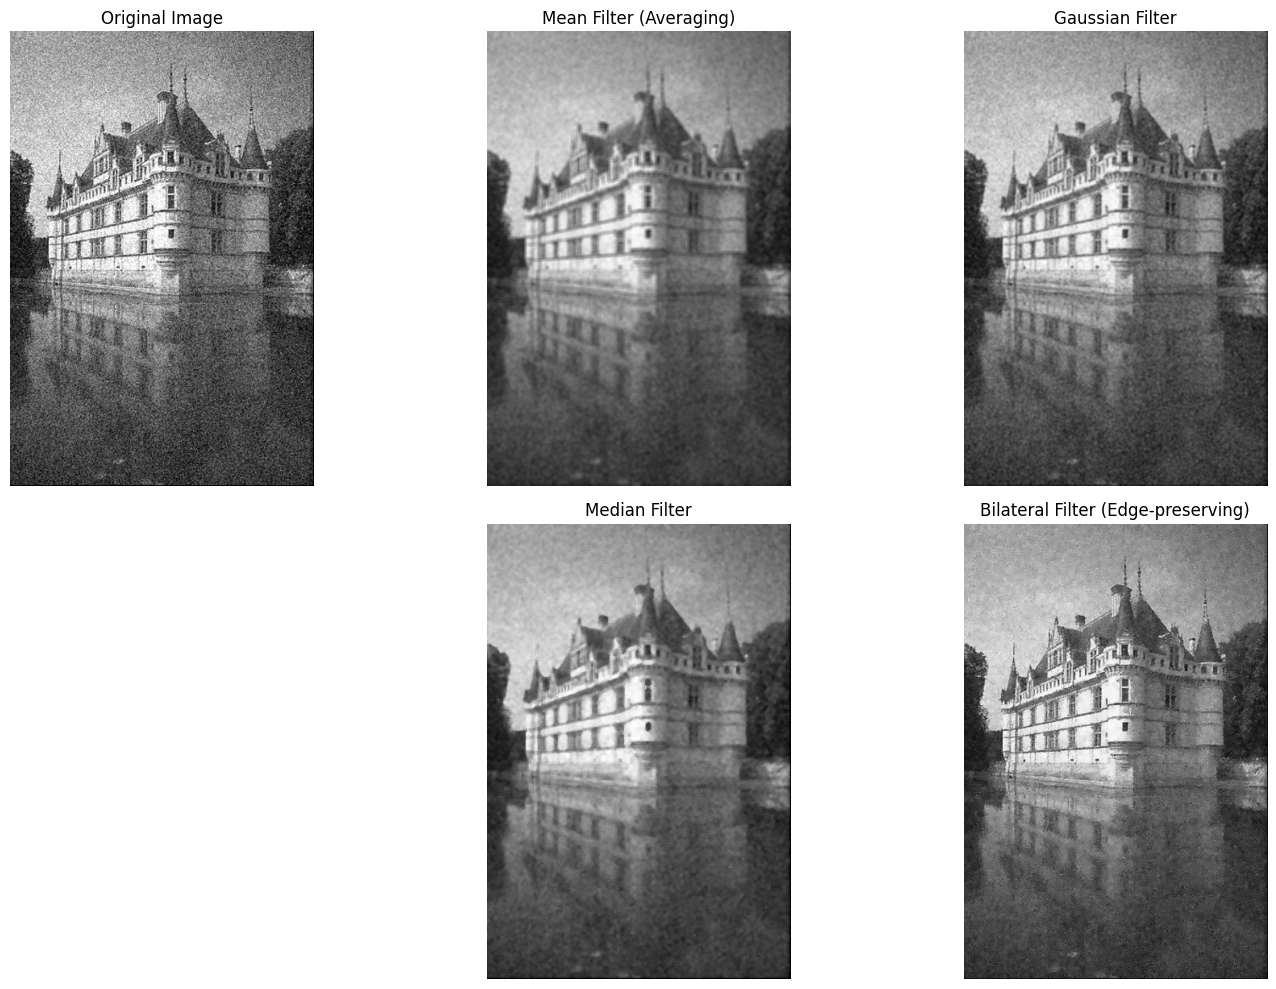

In [8]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(mean_rgb)
plt.title("Mean Filter (Averaging)")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(gaussian_rgb)
plt.title("Gaussian Filter")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(median_rgb)
plt.title("Median Filter")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(bilateral_rgb)
plt.title("Bilateral Filter (Edge-preserving)")
plt.axis('off')

plt.tight_layout()
plt.show()